# Exploratory Data Analysis: Telco Customer Churn

**Purpose:** Understand the structure, distributions, and churn correlations in the raw Telco dataset before any modelling.

**Notebook Structure:**
1. Setup & Data Loading
2. Dataset Overview
3. Target Variable Analysis (Churn)
4. Univariate Analysis — Demographics
5. Univariate Analysis — Services
6. Univariate Analysis — Account & Billing
7. Bivariate Analysis — Churn vs Key Features
8. Correlation Analysis
9. Key Findings Summary

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import sys
import os

warnings.filterwarnings('ignore')

# Add project root to path so we can import from src/
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.utils import RAW_DATA_PATH, summarise_dataframe

# ── Plot styling ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

CHURN_PALETTE = {'No': '#4C72B0', 'Yes': '#DD8452'}

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load the raw dataset directly for EDA 
df = pd.read_csv(RAW_DATA_PATH)
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 7,043 rows × 21 columns


## 2. Dataset Overview

Before any visualisation, we need to understand what we're working with: data types, nulls, and basic structure.

In [3]:
print('=== SHAPE ===')
print(f'{df.shape[0]:,} customers × {df.shape[1]} features\n')

print('=== DATA TYPES ===')
print(df.dtypes)

print('\n=== NULL VALUES ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No nulls in raw data.')

=== SHAPE ===
7,043 customers × 21 features

=== DATA TYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== NULL VALUES ===
No nulls in raw data.


In [4]:
# TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
total_charges_nulls = df['TotalCharges'].isnull().sum()
print(f'TotalCharges nulls after coercion: {total_charges_nulls}')

# Inspect these rows
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

TotalCharges nulls after coercion: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


**Finding:** The 11 null TotalCharges rows all have tenure = 0. These are brand-new customers who haven't been billed yet. We'll handle this in the cleaning step by imputing with MonthlyCharges.

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Target Variable Analysis: Churn

Understanding class distribution is critical before modelling. Imbalanced classes require specific handling.

In [6]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Churn Distribution:')
print(f"  No  (Retained) : {churn_counts['No']:,}  ({churn_pct['No']:.1f}%)")
print(f"  Yes (Churned)  : {churn_counts['Yes']:,}  ({churn_pct['Yes']:.1f}%)")
print(f"\n  Class ratio    : {churn_counts['No']/churn_counts['Yes']:.1f}:1")

Churn Distribution:
  No  (Retained) : 5,174  (73.5%)
  Yes (Churned)  : 1,869  (26.5%)

  Class ratio    : 2.8:1


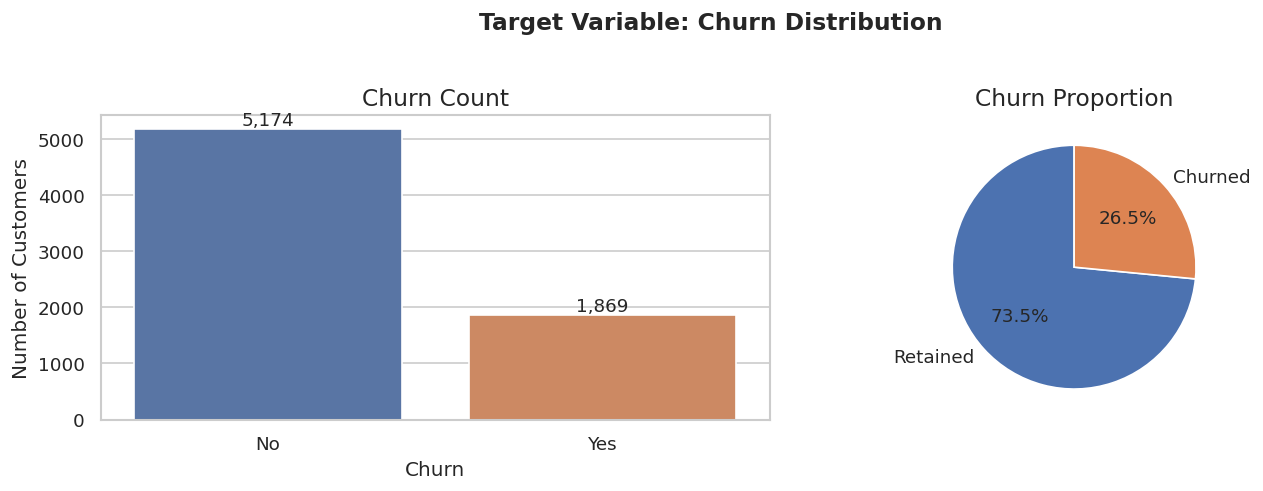

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=df, x='Churn', palette=CHURN_PALETTE, ax=axes[0], order=['No', 'Yes'])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(churn_counts, labels=['Retained', 'Churned'], 
            colors=[CHURN_PALETTE['No'], CHURN_PALETTE['Yes']],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Churn Proportion')

plt.suptitle('Target Variable: Churn Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Finding:** ~26.5% churn rate. This is a moderately imbalanced dataset. We'll use SMOTE or class_weight='balanced' during modelling to address this.

## 4. Univariate Analysis: Demographics

Understand the makeup of our customer base before examining churn relationships.

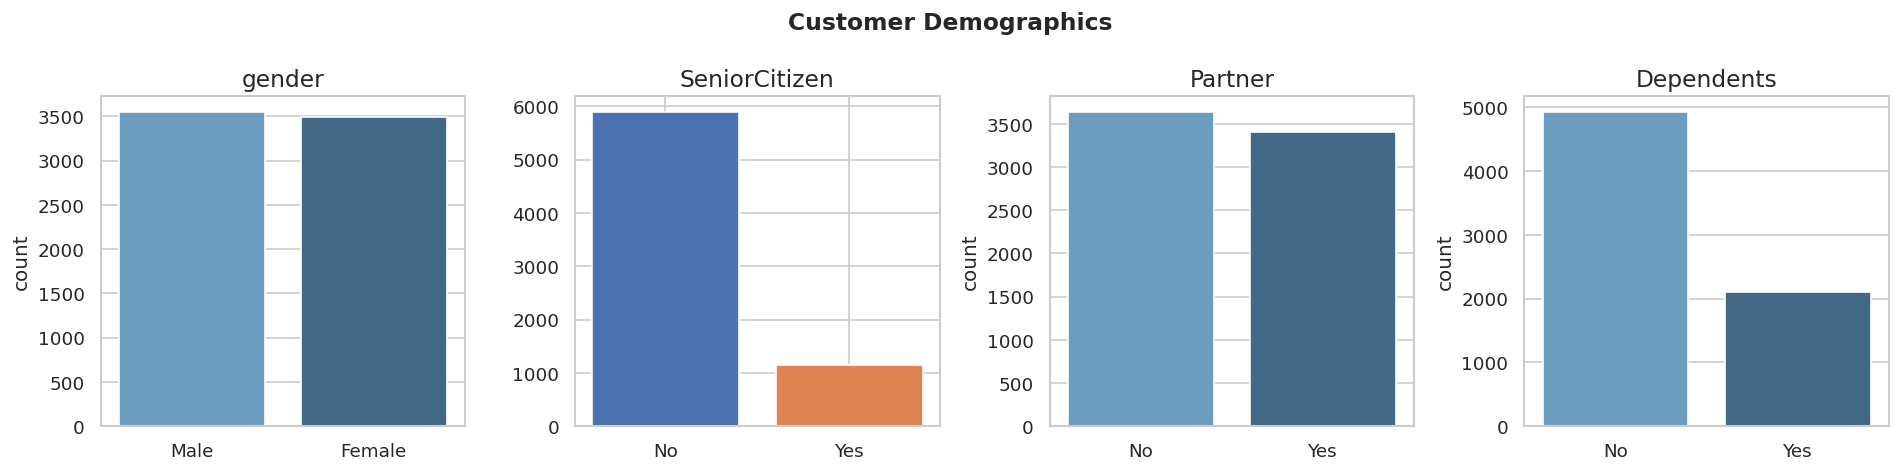

In [8]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(demo_cols):
    if df[col].dtype == 'object':
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, ax=axes[i], palette='Blues_d', order=order)
    else:
        # SeniorCitizen is 0/1
        temp = df[col].map({0: 'No', 1: 'Yes'}).value_counts()
        axes[i].bar(temp.index, temp.values, color=['#4C72B0', '#DD8452'])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Customer Demographics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Univariate Analysis: Services

Which services are most popular? High service adoption typically correlates with retention.

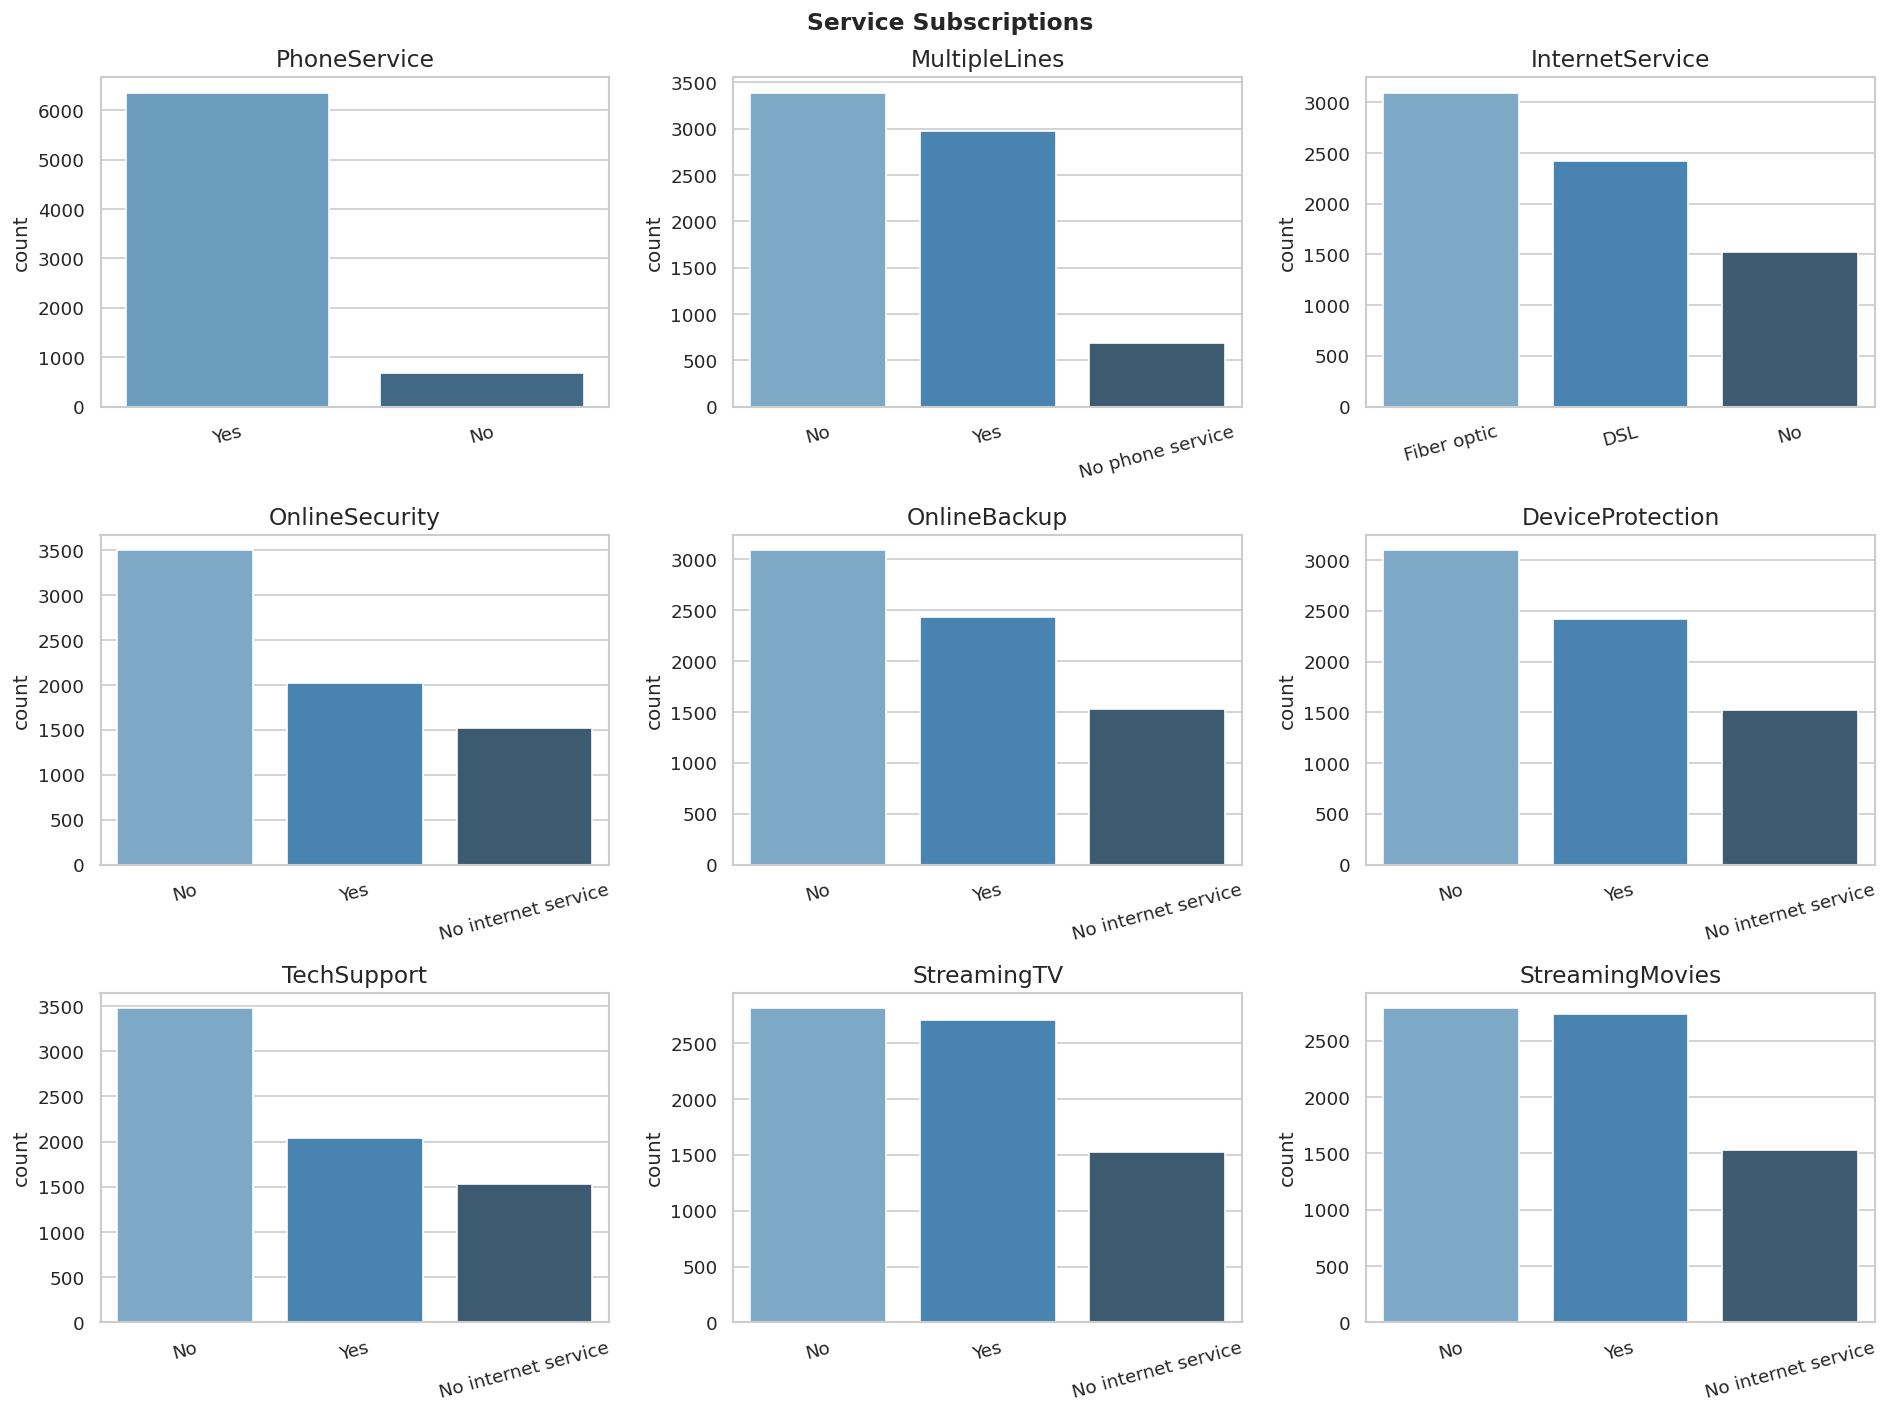

In [9]:
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], palette='Blues_d', order=order)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Service Subscriptions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Univariate Analysis: Account & Billing

Billing and contract details are among the strongest churn predictors in telecom datasets.

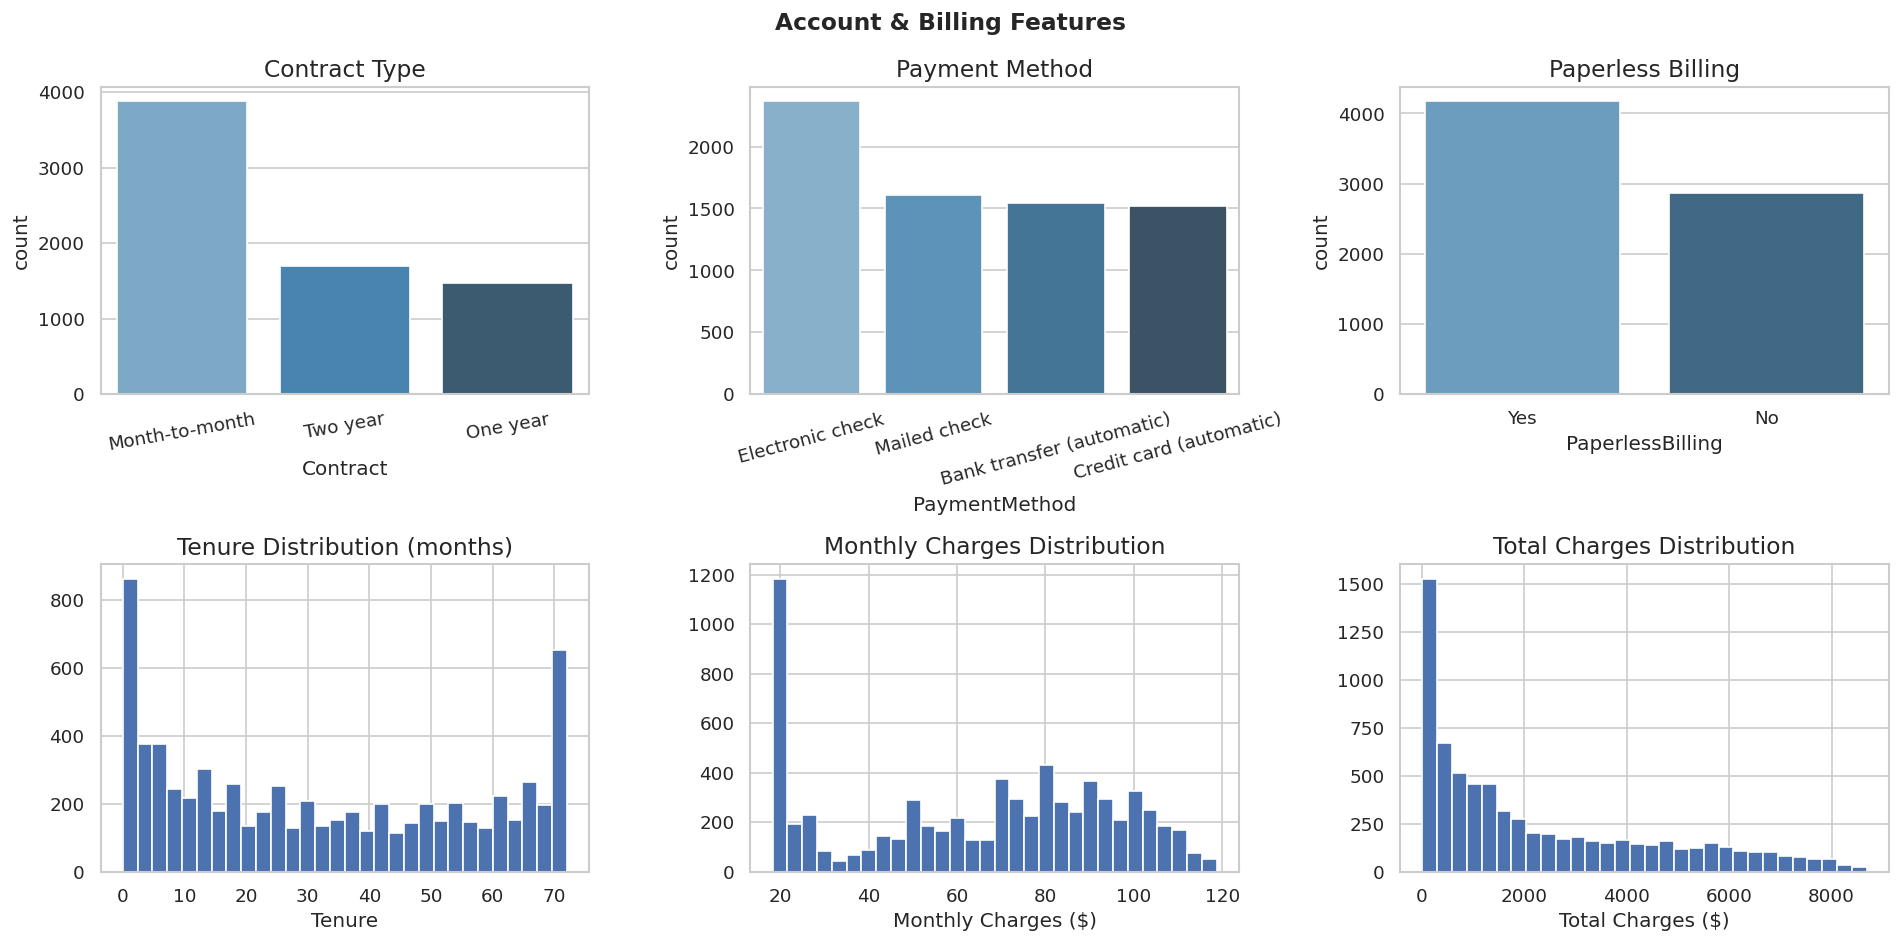

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Contract type
order = df['Contract'].value_counts().index
sns.countplot(data=df, x='Contract', ax=axes[0,0], palette='Blues_d', order=order)
axes[0,0].set_title('Contract Type')
axes[0,0].tick_params(axis='x', rotation=10)

# Payment method
order = df['PaymentMethod'].value_counts().index
sns.countplot(data=df, x='PaymentMethod', ax=axes[0,1], palette='Blues_d', order=order)
axes[0,1].set_title('Payment Method')
axes[0,1].tick_params(axis='x', rotation=15)

# Paperless billing
sns.countplot(data=df, x='PaperlessBilling', ax=axes[0,2], palette='Blues_d')
axes[0,2].set_title('Paperless Billing')

# Tenure distribution
axes[1,0].hist(df['tenure'], bins=30, color='#4C72B0', edgecolor='white')
axes[1,0].set_title('Tenure Distribution (months)')
axes[1,0].set_xlabel('Tenure')

# Monthly charges distribution
axes[1,1].hist(df['MonthlyCharges'], bins=30, color='#4C72B0', edgecolor='white')
axes[1,1].set_title('Monthly Charges Distribution')
axes[1,1].set_xlabel('Monthly Charges ($)')

# Total charges distribution
axes[1,2].hist(df['TotalCharges'].dropna(), bins=30, color='#4C72B0', edgecolor='white')
axes[1,2].set_title('Total Charges Distribution')
axes[1,2].set_xlabel('Total Charges ($)')

plt.suptitle('Account & Billing Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Bivariate Analysis: Churn vs Key Features

This is the core of our EDA — understanding which features are most associated with churn.

In [11]:
def churn_rate_by_category(df, col, ax, title=None):
    """Plot churn rate for each category of a given column."""
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'churn_rate']
    churn_rate = churn_rate.sort_values('churn_rate', ascending=False)
    
    bars = ax.barh(churn_rate[col], churn_rate['churn_rate'], color='#DD8452')
    ax.axvline(x=26.5, linestyle='--', color='gray', alpha=0.7, label='Overall avg')
    ax.set_xlabel('Churn Rate (%)')
    ax.set_title(title or col)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    
    for bar, val in zip(bars, churn_rate['churn_rate']):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

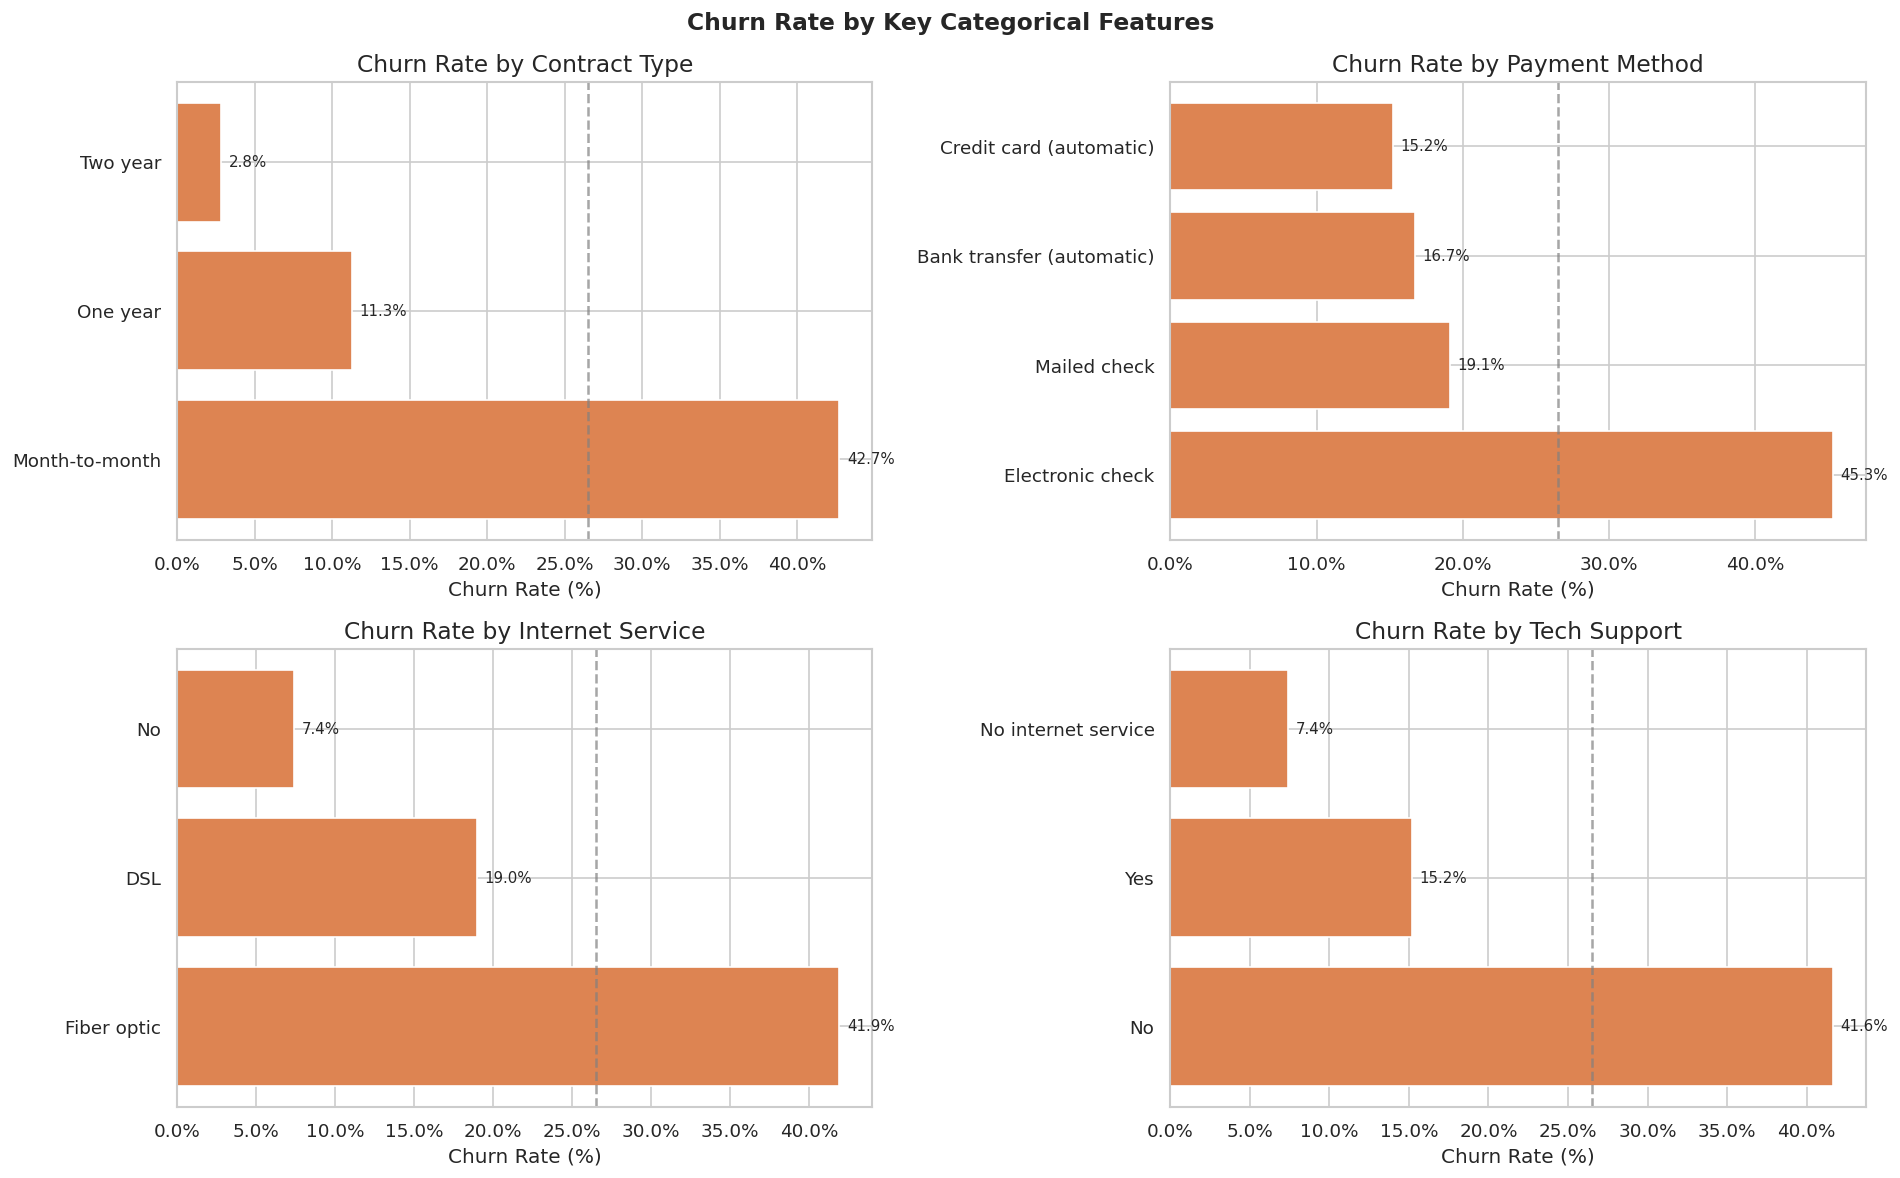

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

churn_rate_by_category(df, 'Contract', axes[0,0], 'Churn Rate by Contract Type')
churn_rate_by_category(df, 'PaymentMethod', axes[0,1], 'Churn Rate by Payment Method')
churn_rate_by_category(df, 'InternetService', axes[1,0], 'Churn Rate by Internet Service')
churn_rate_by_category(df, 'TechSupport', axes[1,1], 'Churn Rate by Tech Support')

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

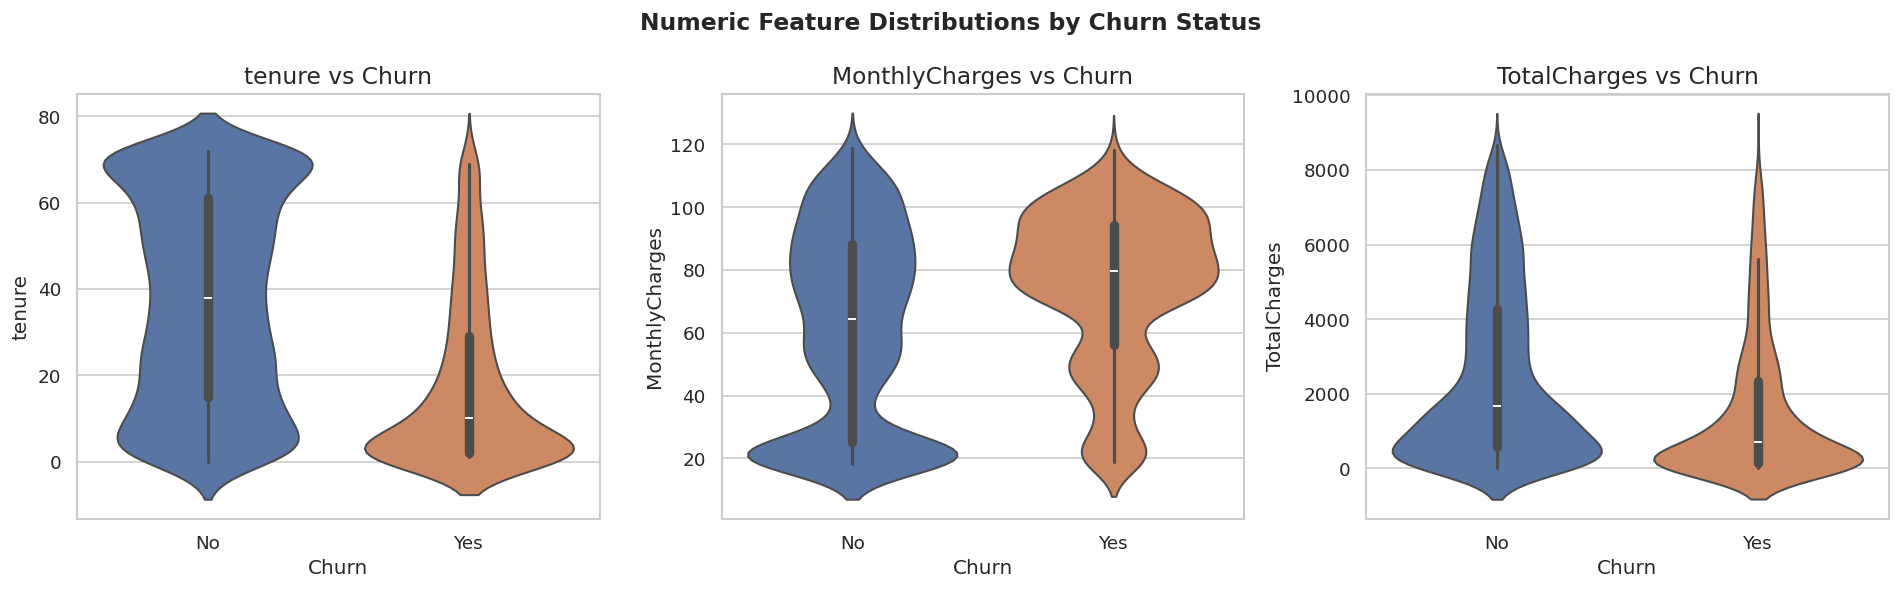

In [13]:
# Numeric features vs churn — violin plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.violinplot(data=df, x='Churn', y=col, palette=CHURN_PALETTE, ax=ax, order=['No', 'Yes'])
    ax.set_title(f'{col} vs Churn')

plt.suptitle('Numeric Feature Distributions by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

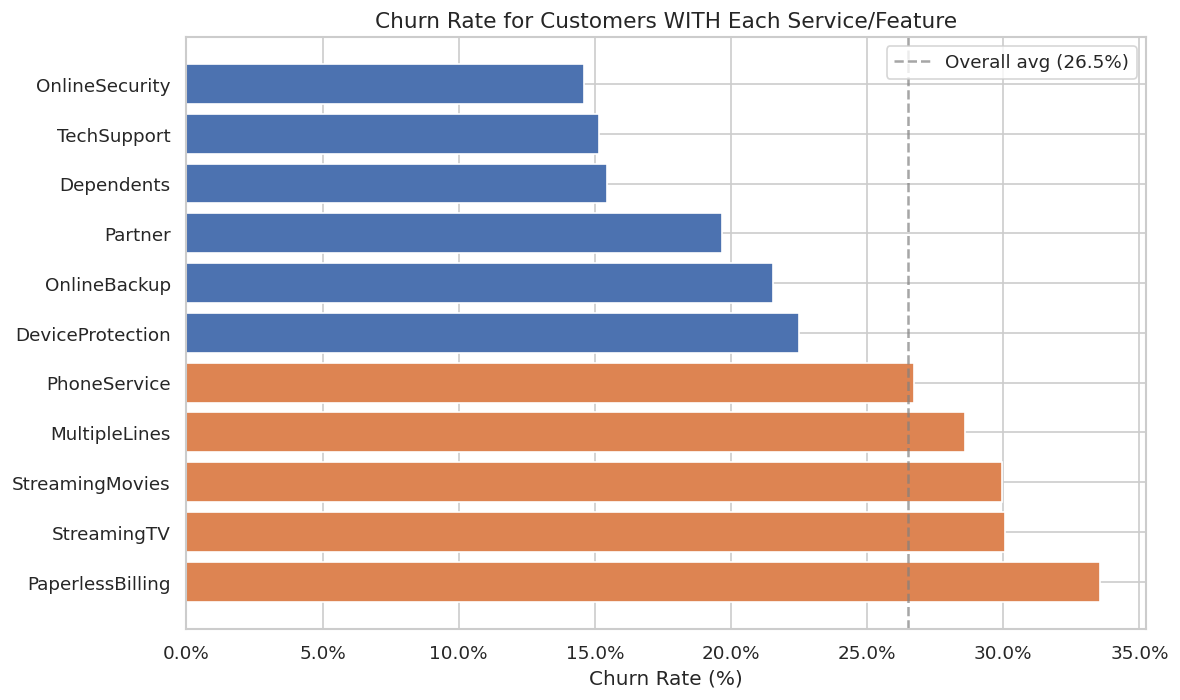

In [14]:
# Churn rate across all binary/categorical service features
binary_service_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'Partner', 'Dependents'
]

# Build summary: churn rate for 'Yes' vs 'No' in each column
rows = []
for col in binary_service_cols:
    for val in df[col].unique():
        subset = df[df[col] == val]
        churn_rate = (subset['Churn'] == 'Yes').mean() * 100
        rows.append({'Feature': col, 'Value': val, 'Churn Rate': churn_rate})

summary = pd.DataFrame(rows)
yes_rates = summary[summary['Value'] == 'Yes'].sort_values('Churn Rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DD8452' if r > 26.5 else '#4C72B0' for r in yes_rates['Churn Rate']]
ax.barh(yes_rates['Feature'], yes_rates['Churn Rate'], color=colors)
ax.axvline(x=26.5, linestyle='--', color='gray', alpha=0.7, label='Overall avg (26.5%)')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate for Customers WITH Each Service/Feature', fontsize=13)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

Numeric correlation matrix to identify multicollinearity before modelling.

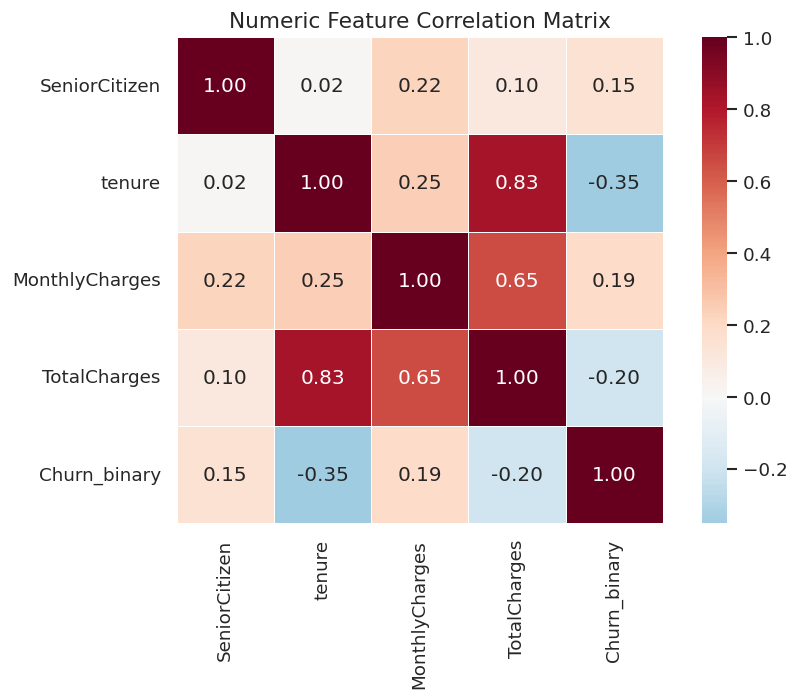

In [15]:
# Encode Churn as binary for correlation
df_corr = df.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)
df_corr['SeniorCitizen'] = df_corr['SeniorCitizen'].astype(int)
df_corr['TotalCharges'] = df_corr['TotalCharges'].fillna(df_corr['MonthlyCharges'])

numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']
corr_matrix = df_corr[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Numeric Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# Correlations with churn specifically — sorted
churn_corr = corr_matrix['Churn_binary'].drop('Churn_binary').sort_values()
print('Correlation with Churn (numeric features only):')
print(churn_corr.to_string())

Correlation with Churn (numeric features only):
tenure           -0.352229
TotalCharges     -0.198347
SeniorCitizen     0.150889
MonthlyCharges    0.193356


## 9. Key Findings Summary

A clear summary of what we learned — this is what goes in your portfolio writeup.

In [17]:
print("""
╔══════════════════════════════════════════════════════════╗
║           EDA KEY FINDINGS SUMMARY                      ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  CHURN RATE                                              ║
║  • Overall churn rate: ~26.5% (moderately imbalanced)   ║
║  • Will require class_weight or SMOTE in modelling      ║
║                                                          ║
║  TOP CHURN PREDICTORS                                    ║
║  • Contract type: Month-to-month ~43% vs 2yr ~3%        ║
║  • Payment: Electronic check ~45% churn rate            ║
║  • Internet: Fiber optic customers churn most           ║
║  • No TechSupport: significantly higher churn           ║
║  • Low tenure: new customers churn at much higher rates ║
║                                                          ║
║  DATA QUALITY                                            ║
║  • 11 TotalCharges nulls (tenure=0 customers)           ║
║  • All handled cleanly in ETL pipeline                  ║
║                                                          ║
║  MULTICOLLINEARITY NOTE                                  ║
║  • tenure and TotalCharges are highly correlated (0.83) ║
║  • Will use TotalCharges as the RFM monetary proxy      ║
║  • Tree-based models handle this without issues         ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║           EDA KEY FINDINGS SUMMARY                      ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  CHURN RATE                                              ║
║  • Overall churn rate: ~26.5% (moderately imbalanced)   ║
║  • Will require class_weight or SMOTE in modelling      ║
║                                                          ║
║  TOP CHURN PREDICTORS                                    ║
║  • Contract type: Month-to-month ~43% vs 2yr ~3%        ║
║  • Payment: Electronic check ~45% churn rate            ║
║  • Internet: Fiber optic customers churn most           ║
║  • No TechSupport: significantly higher churn           ║
║  • Low tenure: new customers churn at much higher rates ║
║                                                          ║
║  DATA QUALITY                                            ║
║  • 11 TotalCharges nulls (ten

## Author

- **Name:** Takunda Madondo